<a href="https://colab.research.google.com/github/semanrbingl/ai-ecommerce-product-generator/blob/main/notebooks/04_gradcam_explainability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Kullanılan cihaz:", device)

Kullanılan cihaz: cuda


In [6]:
import kagglehub
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")
DATA_DIR = path
print(DATA_DIR)


100%|██████████| 565M/565M [00:09<00:00, 61.1MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/paramaggarwal/fashion-product-images-small/versions/1


In [7]:
import os
import pandas as pd

df = pd.read_csv(os.path.join(DATA_DIR, "styles.csv"), on_bad_lines="skip")
df["image_path"] = df["id"].astype(str).apply(
    lambda x: os.path.join(DATA_DIR, "images", x + ".jpg")
)
df = df[df["image_path"].apply(os.path.exists)].reset_index(drop=True)

TOP_N = 20
MIN_SAMPLES = 500
counts = df["articleType"].value_counts()
raw_counts = counts.head(TOP_N)
top_classes = raw_counts[raw_counts >= MIN_SAMPLES].index.tolist()

df_model = df[df["articleType"].isin(top_classes)].reset_index(drop=True).copy()

class_names = sorted(df_model["articleType"].unique())
class_to_idx = {name: i for i, name in enumerate(class_names)}
idx_to_class = {i: name for name, i in class_to_idx.items()}

df_model["label"] = df_model["articleType"].map(class_to_idx)

print("Sınıf sayısı:", len(class_names))
print("Toplam görsel:", len(df_model))

Sınıf sayısı: 20
Toplam görsel: 33142


In [8]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(
    df_model, test_size=0.30, stratify=df_model["label"], random_state=42
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label"], random_state=42
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("Test:", len(test_df))

Test: 4972


In [9]:
from google.colab import drive
drive.mount('/content/drive')

from torchvision import models
import torch.nn as nn

SAVE_DIR = "/content/drive/MyDrive/ai_ecommerce_product_generator"
checkpoint_path = os.path.join(SAVE_DIR, "baseline_resnet50.pth")
checkpoint = torch.load(checkpoint_path, map_location=device)

num_classes = len(checkpoint["class_to_idx"])
model = models.resnet50(weights=None)
model.fc = nn.Linear(model.fc.in_features, num_classes)
model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Model yüklendi, sınıf sayısı:", num_classes)

Mounted at /content/drive
Model yüklendi, sınıf sayısı: 20


In [10]:
activations = {}
gradients = {}

def forward_hook(module, input, output):
  activations["value"] = output.detach()

def backward_hook(module, grad_input, grad_output):
  gradients["value"] = grad_output[0].detach()

target_layer = model.layer4
handle_forward = target_layer.register_forward_hook(forward_hook)
handle_backward = target_layer.register_full_backward_hook(backward_hook)

print("Hook'lar bağlandı.")

Hook'lar bağlandı.


In [11]:
from torchvision import transforms
from PIL import Image
import numpy as np
import cv2  #OpenCV görsel işleme için kullanılan kütüphane

IMG_SIZE = 224
imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=imagenet_mean, std=imagenet_std),
])


def generate_gradcam(image_path, model, target_class=None):
  image = Image.open(image_path).convert("RGB")
  input_tensor = eval_transform(image).unsqueeze(0).to(device)


  model.zero_grad()
  output = model(input_tensor)

  if target_class is None:
      target_class = output.argmax(dim=1).item()

  score = output[0, target_class]
  score.backward()

  act = activations["value"][0]
  grad = gradients["value"][0]

  weights = grad.mean(dim=(1, 2))


  cam = torch.zeros(act.shape[1:], device=device)
  for i, w in enumerate(weights):
      cam += w * act[i]

  cam = torch.relu(cam)
  cam = cam.cpu().numpy()
  cam = cv2.resize(cam, (IMG_SIZE, IMG_SIZE))
  cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

  return cam, target_class, torch.softmax(output, dim=1)[0, target_class].item()

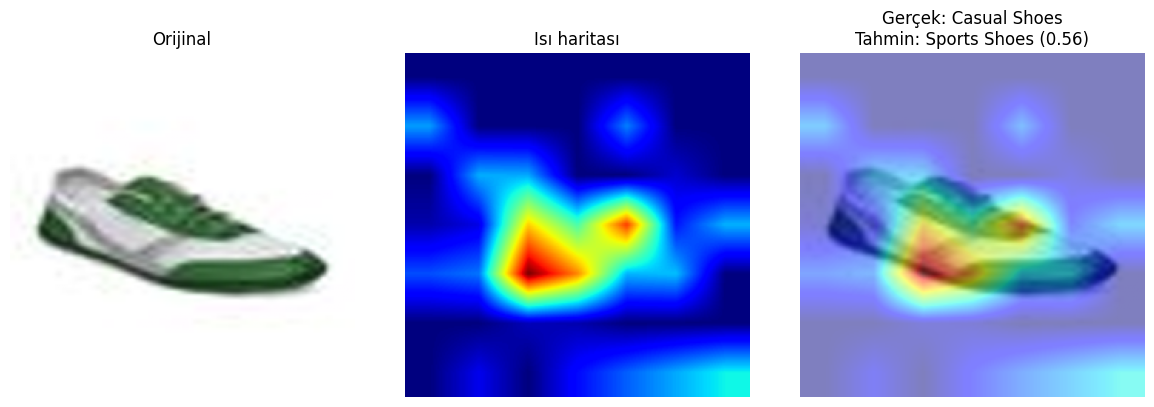

In [13]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

def show_gradcam(image_path, model, target_class=None, true_class=None):
    cam, pred_idx, confidence = generate_gradcam(image_path, model, target_class)
    pred_class = idx_to_class[pred_idx]

    original = Image.open(image_path).convert("RGB").resize((IMG_SIZE, IMG_SIZE))
    original_np = np.array(original) / 255.0

    heatmap = cm.jet(cam)[:, :, :3]
    overlay = 0.5 * original_np + 0.5 * heatmap

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(original_np)
    axes[0].set_title("Orijinal")
    axes[0].axis("off")

    axes[1].imshow(cam, cmap="jet")
    axes[1].set_title("Isı haritası")
    axes[1].axis("off")

    axes[2].imshow(overlay)
    title = f"Tahmin: {pred_class} ({confidence:.2f})"
    if true_class:
        title = f"Gerçek: {true_class}\n{title}"
    axes[2].set_title(title)
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

sample_row = test_df.sample(1, random_state=1).iloc[0]
show_gradcam(sample_row["image_path"], model, true_class=sample_row["articleType"])

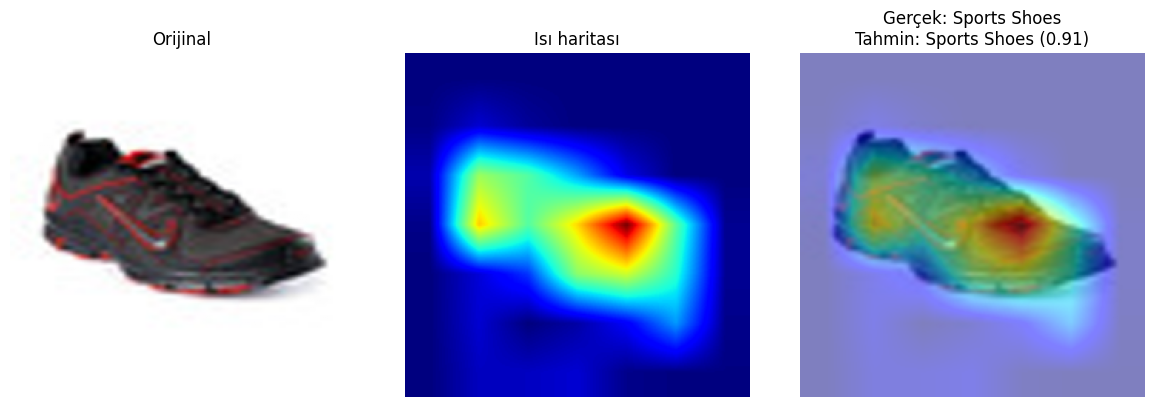

In [14]:
correct_examples = test_df[test_df["label"].map(idx_to_class)== test_df["articleType"]]
sample_row = test_df[test_df['articleType'] == "Sports Shoes"].sample(1, random_state=3).iloc[0]
show_gradcam(sample_row["image_path"], model, true_class=sample_row["articleType"])

Bulundu: index 6, confidence 0.92


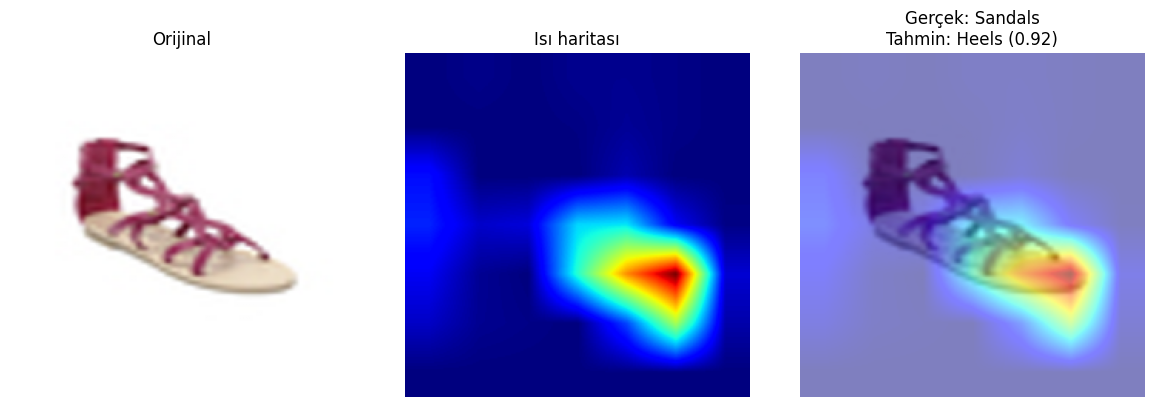

In [15]:
sandals_df = test_df[test_df["articleType"] == "Sandals"].reset_index(drop=True)

for i in range(len(sandals_df)):
    row = sandals_df.iloc[i]
    cam, pred_idx, conf = generate_gradcam(row["image_path"], model)
    pred_class = idx_to_class[pred_idx]
    if pred_class == "Heels":
        print(f"Bulundu: index {i}, confidence {conf:.2f}")
        show_gradcam(row["image_path"], model, true_class="Sandals")
        break

Bulundu: index 10, confidence 0.86


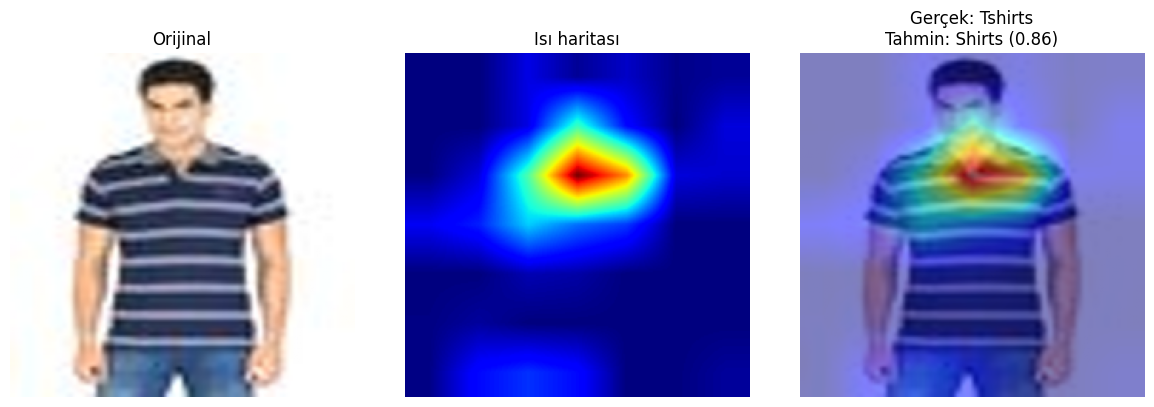

In [16]:
tshirts_df = test_df[test_df["articleType"] == "Tshirts"].reset_index(drop=True)

for i in range(len(tshirts_df)):
    row = tshirts_df.iloc[i]
    cam, pred_idx, conf = generate_gradcam(row["image_path"], model)
    pred_class = idx_to_class[pred_idx]
    if pred_class == "Shirts":
        print(f"Bulundu: index {i}, confidence {conf:.2f}")
        show_gradcam(row["image_path"], model, true_class="Tshirts")
        break

ÖZET

Doğru ve emin tahminlerde (Sports Shoes, 0.91) dikkat geniş bir alanı kapsıyor.
Yanlış/kararsız tahminlerde (Casual→Sports Shoes, 0.56) dikkat dar ve dağınık.

İki farklı yüksek-confidence hata türü bulundu:
- **Sandals→Heels (0.92):** Model yanlış özelliğe (kayış deseni) bakmış — gerçek model zayıflığı.
- **Tshirts→Shirts (0.86):** Model doğru özelliğe (yaka) bakmış — dataset'in kategori sınırı belirsiz.

**Sonuç:** Confidence, hem doğruluğu hem dikkatin ne kadar "toplu" olduğunu yansıtıyor.